# How Should Apples be Prepared for a Fruit Salad?

By the end of this module, you should be able to answer this question! More specifically, you should be able to use the data collected by you and your classmates to select the best varietals of apple, choose inhibitors of the browning process, and explain how the inhibitors work to slow browning.

This is a script for importing data from text files *within a working directory*. To use this template 'as is', please create a directory and put all the files that you wish to import within that directory.

## Attribution:

This code was developed by Dora Geng and Dr. Kathryn Haas (2024, CC-BY-NC-SA) with assistance from ChatGPT. Converted to Python in 2026.

Parts I and II of this experiment are adapted from:
- Cole, Renée S., Marc Muniz, Erica Harvey, Robert Sweeney, and **Sally Hunnicutt**. "How Should Apples Be Prepared for a Fruit Salad? A Guided Inquiry Physical Chemistry Experiment." *Journal of Chemical Education* 97, no. 12 (December 8, 2020): 4475–81. https://doi.org/10.1021/acs.jchemed.0c00517.
- Fun Fact: Sally Hunnicutt is a Duke Alum! Chemistry Major '83

## Import Required Libraries
### This code loads the tools we will use

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import warnings
import os
warnings.filterwarnings('ignore')

## Read your data files into memory
# Questions:  
1.  What command is used to read a data file in python?
2.  Why do we skip the first 21 rows in the data file?  (Look at the data files and think about the experiment)
3.  How many rows of data do we read in?  (What "number of rows" are read in?)
4.  Add code to read in Run number 3.
5.  Look at the output and verify that it is reading the data as you expect.

In [ ]:
Run1 = pd.read_csv("20250227_Part1_EMPIRE/20250227_Part1_EMPIRE_Run1.txt", 
                   sep="\t", skiprows=21, nrows=50,
                   names=["Time", "Transmittance", "Absorbance"])
Run2 = pd.read_csv("20250227_Part1_EMPIRE/20250227_Part1_EMPIRE_Run2.txt", 
                   sep="\t", skiprows=21, nrows=50,
                   names=["Time", "Transmittance", "Absorbance"])

# add code to read in Run3 here
Run3 = 


print ("The first five rows of Run1 are:")
Run1.head(5)

The first five rows of Run1 are:


,Time,Transmittance,Absorbance
0,28.0,97.678726,0.0102
1,30.0,97.678726,0.0102
2,32.0,97.588806,0.0106
3,34.0,97.633759,0.0104
4,36.0,97.746223,0.0099


In [ ]:
Run1 = pd.read_csv("20250227_Part1_EMPIRE/20250227_Part1_EMPIRE_Run1.txt", 
                   sep="\t", skiprows=21, nrows=50,
                   names=["Time", "Transmittance", "Absorbance"])
Run2 = pd.read_csv("20250227_Part1_EMPIRE/20250227_Part1_EMPIRE_Run2.txt", 
                   sep="\t", skiprows=21, nrows=50,
                   names=["Time", "Transmittance", "Absorbance"])
Run3 = pd.read_csv("20250227_Part1_EMPIRE/20250227_Part1_EMPIRE_Run3.txt", 
                   sep="\t", skiprows=21, nrows=50,
                   names=["Time", "Transmittance", "Absorbance"])


# print out the first five rows of Run1
Run1.head(5)

# Dataframes are like Excel Worksheets
## Data is stored in rows and columns, just like Excel
## Questions
1.  In python, how do we represent "The Time column in the dataframe (worksheet) named Run1"?
2.  Change the code to instead print out the values in the Absorbance column for Run 2

In [ ]:
# change the code to print the absorbance column of Run 2 instead of the Time column of Run 1:
print (Run1['Time'])



0      28.0
1      30.0
2      32.0
3      34.0
4      36.0
5      38.0
6      40.0
7      42.0
8      44.0
9      46.0
10     48.0
11     50.0
12     52.0
13     54.0
14     56.0
15     58.0
16     60.0
17     62.0
18     64.0
19     66.0
20     68.0
21     70.0
22     72.0
23     74.0
24     76.0
25     78.0
26     80.0
27     82.0
28     84.0
29     86.0
30     88.0
31     90.0
32     92.0
33     94.0
34     96.0
35     98.0
36    100.0
37    102.0
38    104.0
39    106.0
40    108.0
41    110.0
42    112.0
43    114.0
44    116.0
45    118.0
46    120.0
47    122.0
48    124.0
49    126.0
Name: Time, dtype: float64


In [ ]:
# change the code to print the absorbance column of Run 2 instead of the Time column of Run 1:
print (Run2['Absorbance'])

0     0.3158
1     0.3171
2     0.3183
3     0.3194
4     0.3202
5     0.3215
6     0.3226
7     0.3238
8     0.3245
9     0.3258
10    0.3270
11    0.3283
12    0.3300
13    0.3312
14    0.3325
15    0.3333
16    0.3348
17    0.3357
18    0.3369
19    0.3384
20    0.3395
21    0.3406
22    0.3419
23    0.3431
24    0.3442
25    0.3444
26    0.3453
27    0.3465
28    0.3473
29    0.3486
30    0.3500
31    0.3513
32    0.3521
33    0.3534
34    0.3546
35    0.3546
36    0.3557
37    0.3564
38    0.3572
39    0.3581
40    0.3590
41    0.3600
42    0.3609
43    0.3617
44    0.3626
45    0.3635
46    0.3643
47    0.3650
48    0.3659
49    0.3665
Name: Absorbance, dtype: float64


# Experiment One: How does apple extract effect the oxidation of catechol? Does pH matter?

## Plotting Absorbance Data

## Questions:

1.  What command is used to add a time series to a plot?
2.  What are the x-values?  What are the y-values?
3.  What command sets the title of the plot?
4.  What does 'o' do in the plt.plot() commands?  try changing 'o' to 'x', '-', 'd'
5.  How does the data look?  If you think we should cut the experiment off earlier, *decrease nrows above and rerun all cells*.
6.  Add code to plot the data from Run 3.  The label will be "Run 3, S+E+buffer"

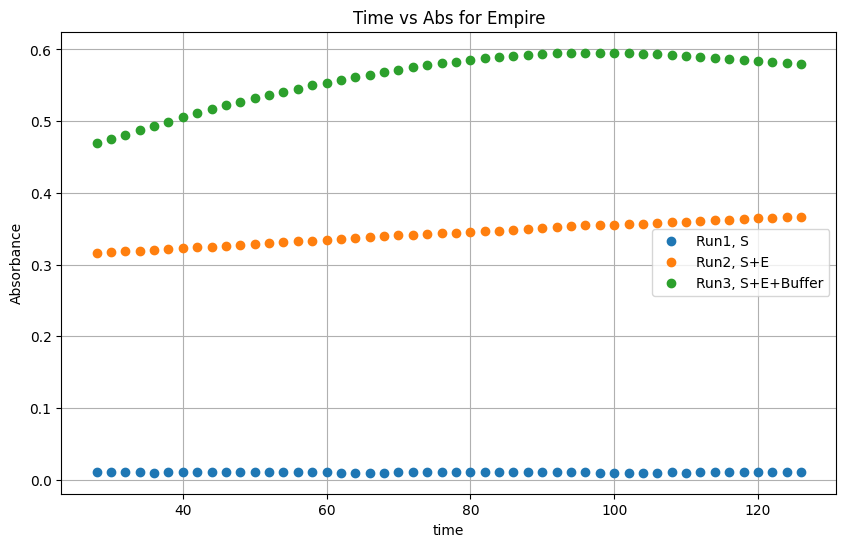

In [ ]:
# Remove data points as necessary
plt.figure(figsize=(10, 6))
plt.plot(Run1['Time'], Run1['Absorbance'], 'o', label='Run1, S')
plt.plot(Run2['Time'], Run2['Absorbance'], 'o', label='Run2, S+E')
# add code to plot Run3 here
plt.plot(  )


plt.title('Time vs Abs for Empire')
plt.xlabel('time')
plt.ylabel('Absorbance')
plt.legend(loc='best')
plt.grid(True)
plt.show()



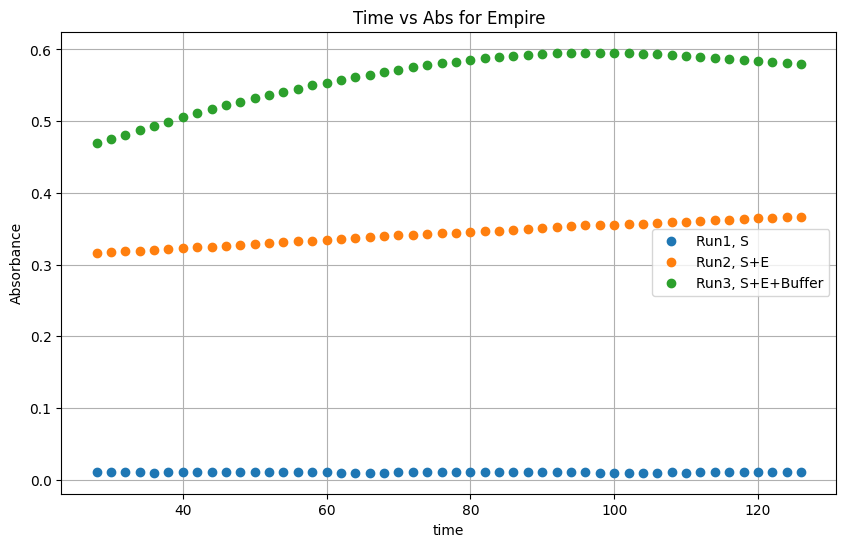

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(Run1['Time'], Run1['Absorbance'], 'o', label='Run1, S')
plt.plot(Run2['Time'], Run2['Absorbance'], 'o', label='Run2, S+E')
plt.plot(Run3['Time'], Run3['Absorbance'], 'o', label='Run3, S+E+Buffer')
plt.title('Time vs Abs for Empire')
plt.xlabel('time')
plt.ylabel('Absorbance')
plt.legend(loc='best')
plt.grid(True)
plt.show()



## Calculate Initial Velocity (rate)



## Questions
1.  What function calculates the derivative of data?
2.  What is being calculated?  The derivative of _______ with respect to ______  This is known as the __________ of the reaction
3.  Add code to calculate the velocity of run 3 and add Run 3's velocity to the plot

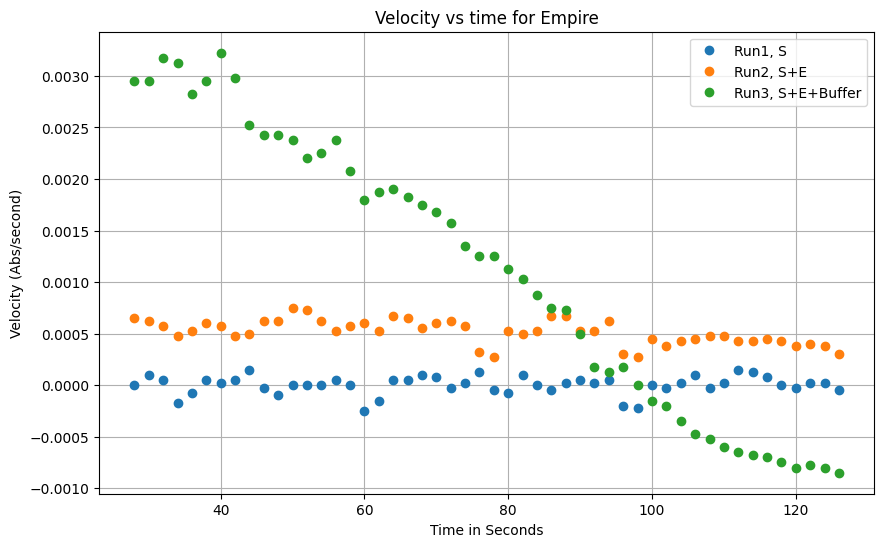

In [ ]:
Run1['Velocity'] = np.gradient(Run1['Absorbance'], Run1['Time'])
Run2['Velocity'] = np.gradient(Run2['Absorbance'], Run2['Time'])
# calculate velocity for Run3 here
Run3['Velocity'] = 

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(Run1['Time'], Run1['Velocity'], 'o', label='Run1, S')
plt.plot(Run2['Time'], Run2['Velocity'], 'o', label='Run2, S+E')
# add code to plot Run3 here

plt.title('Velocity vs time for Empire')
plt.xlabel('Time in Seconds')
plt.ylabel('Velocity (Abs/second)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

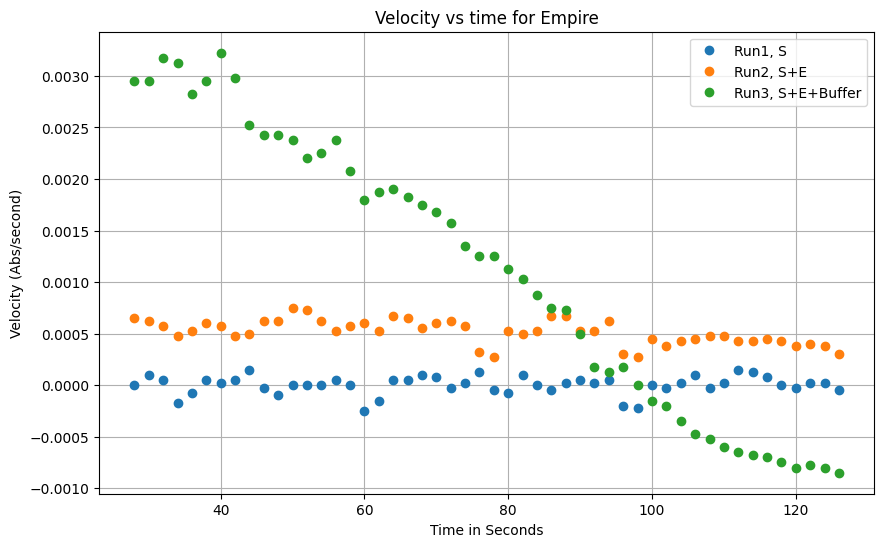

In [ ]:
Run1['Velocity'] = np.gradient(Run1['Absorbance'], Run1['Time'])
Run2['Velocity'] = np.gradient(Run2['Absorbance'], Run2['Time'])
Run3['Velocity'] = np.gradient(Run3['Absorbance'], Run3['Time'])

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(Run1['Time'], Run1['Velocity'], 'o', label='Run1, S')
plt.plot(Run2['Time'], Run2['Velocity'], 'o', label='Run2, S+E')
plt.plot(Run3['Time'], Run3['Velocity'], 'o', label='Run3, S+E+Buffer')
plt.title('Velocity vs time for Empire')
plt.xlabel('Time in Seconds')
plt.ylabel('Velocity (Abs/second)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## The y-intercept (at time zero) is the initial velocity (rate) of the reaction.
### Use linear regression to fit a straight line to the data

## Questions
1.  What function is used to calculate a linear regression?  How are the x and y variables specified?
2.  Add code to calculate the linear regression for Run3
3.  What stats does linregress give you?



In [ ]:
# Calculate a linear regression to find V0 (the intercept) and its uncertainty (intercept_stderr)
Run1_fit = stats.linregress(Run1['Time'], Run1['Velocity'])

Run2_fit = stats.linregress(Run2['Time'], Run2['Velocity'])

# add code to fit Run3 here
Run3_fit = 

# Display results
print(f'V0 Run1: {Run1_fit.intercept:.2e} ± {Run1_fit.intercept_stderr:.2e}')
print(f'V0 Run2: {Run2_fit.intercept:.2e} ± {Run2_fit.intercept_stderr:.2e}')
print(f'V0 Run3: {Run3_fit.intercept:.2e} ± {Run3_fit.intercept_stderr:.2e}')

# Display full fit statistics
print("\nRun1 fit statistics:")
print(f"  Slope: {Run1_fit.slope:.6e} ± {Run1_fit.stderr:.6e}")
print(f"  Intercept: {Run1_fit.intercept:.6e} ± {Run1_fit.intercept_stderr:.6e}")
print(f"  R-squared: {Run1_fit.rvalue**2:.6f}")

print("\nRun2 fit statistics:")
print(f"  Slope: {Run2_fit.slope:.6e} ± {Run2_fit.stderr:.6e}")
print(f"  Intercept: {Run2_fit.intercept:.6e} ± {Run2_fit.intercept_stderr:.6e}")
print(f"  R-squared: {Run2_fit.rvalue**2:.6f}")

print("\nRun3 fit statistics:")
print(f"  Slope: {Run3_fit.slope:.6e} ± {Run3_fit.stderr:.6e}")
print(f"  Intercept: {Run3_fit.intercept:.6e} ± {Run3_fit.intercept_stderr:.6e}")
print(f"  R-squared: {Run3_fit.rvalue**2:.6f}")

V0 Run1: -1.22e-05 ± 3.62e-05
V0 Run2: 7.06e-04 ± 3.85e-05
V0 Run3: 4.68e-03 ± 7.47e-05

Run1 fit statistics:
  Slope: 2.034886e-07 ± 4.407079e-07
  Intercept: -1.216880e-05 ± 3.624002e-05
  R-squared: 0.004422

Run2 fit statistics:
  Slope: -2.457973e-06 ± 4.686708e-07
  Intercept: 7.057637e-04 ± 3.853945e-05
  R-squared: 0.364284

Run3 fit statistics:
  Slope: -4.621373e-05 ± 9.078937e-07
  Intercept: 4.683457e-03 ± 7.465735e-05
  R-squared: 0.981811


In [ ]:
# Calculate a linear regression to find V0 (the intercept) and its uncertainty (intercept_stderr)
Run1_fit = stats.linregress(Run1['Time'], Run1['Velocity'])

Run2_fit = stats.linregress(Run2['Time'], Run2['Velocity'])

Run3_fit = stats.linregress(Run3['Time'], Run3['Velocity'])


# Display results
print(f'V0 Run1: {Run1_fit.intercept:.2e} ± {Run1_fit.intercept_stderr:.2e}')
print(f'V0 Run2: {Run2_fit.intercept:.2e} ± {Run2_fit.intercept_stderr:.2e}')
print(f'V0 Run3: {Run3_fit.intercept:.2e} ± {Run3_fit.intercept_stderr:.2e}')

# Display full fit statistics
print("\nRun1 fit statistics:")
print(f"  Slope: {Run1_fit.slope:.6e} ± {Run1_fit.stderr:.6e}")
print(f"  Intercept: {Run1_fit.intercept:.6e} ± {Run1_fit.intercept_stderr:.6e}")
print(f"  R-squared: {Run1_fit.rvalue**2:.6f}")

print("\nRun2 fit statistics:")
print(f"  Slope: {Run2_fit.slope:.6e} ± {Run2_fit.stderr:.6e}")
print(f"  Intercept: {Run2_fit.intercept:.6e} ± {Run2_fit.intercept_stderr:.6e}")
print(f"  R-squared: {Run2_fit.rvalue**2:.6f}")

print("\nRun3 fit statistics:")
print(f"  Slope: {Run3_fit.slope:.6e} ± {Run3_fit.stderr:.6e}")
print(f"  Intercept: {Run3_fit.intercept:.6e} ± {Run3_fit.intercept_stderr:.6e}")
print(f"  R-squared: {Run3_fit.rvalue**2:.6f}")

V0 Run1: -1.22e-05 ± 3.62e-05
V0 Run2: 7.06e-04 ± 3.85e-05
V0 Run3: 4.68e-03 ± 7.47e-05

Run1 fit statistics:
  Slope: 2.034886e-07 ± 4.407079e-07
  Intercept: -1.216880e-05 ± 3.624002e-05
  R-squared: 0.004422

Run2 fit statistics:
  Slope: -2.457973e-06 ± 4.686708e-07
  Intercept: 7.057637e-04 ± 3.853945e-05
  R-squared: 0.364284

Run3 fit statistics:
  Slope: -4.621373e-05 ± 9.078937e-07
  Intercept: 4.683457e-03 ± 7.465735e-05
  R-squared: 0.981811


## Plot the fitted velocity vs time data

Check the data and the plot features. Adjust as necessary.

## Questions
1.  Run1['yfit'] generates a new column of data.  What will its values represent?
2.  Add code to calculate Run3['yfit']

In [ ]:
Run1['yfit'] = Run1_fit.slope * Run1['Time'] + Run1_fit.intercept
Run2['yfit'] = Run2_fit.slope * Run2['Time'] + Run2_fit.intercept
# add code to calculate yfit for Run3 here
Run3['yfit'] = 

plt.figure(figsize=(10, 6))
plt.plot(Run1['Time'], Run1['Velocity'], 'o', label='Run1 data')
plt.plot(Run2['Time'], Run2['Velocity'], 'x', label='Run2 data')
plt.plot(Run3['Time'], Run3['Velocity'], '*', label='Run3 data')
plt.plot(Run1['Time'], Run1['yfit'], 'r-.', label=f'Run1: y = {Run1_fit.slope:.3e}x + {Run1_fit.intercept:.3e}')
plt.plot(Run2['Time'], Run2['yfit'], 'g-.', label=f'Run2: y = {Run2_fit.slope:.3e}x + {Run2_fit.intercept:.3e}')
plt.plot(Run3['Time'], Run3['yfit'], 'b-.', label=f'Run3: y = {Run3_fit.slope:.3e}x + {Run3_fit.intercept:.3e}')
plt.title('Velocity vs Time for Empire')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best')
plt.grid(True)
plt.show()

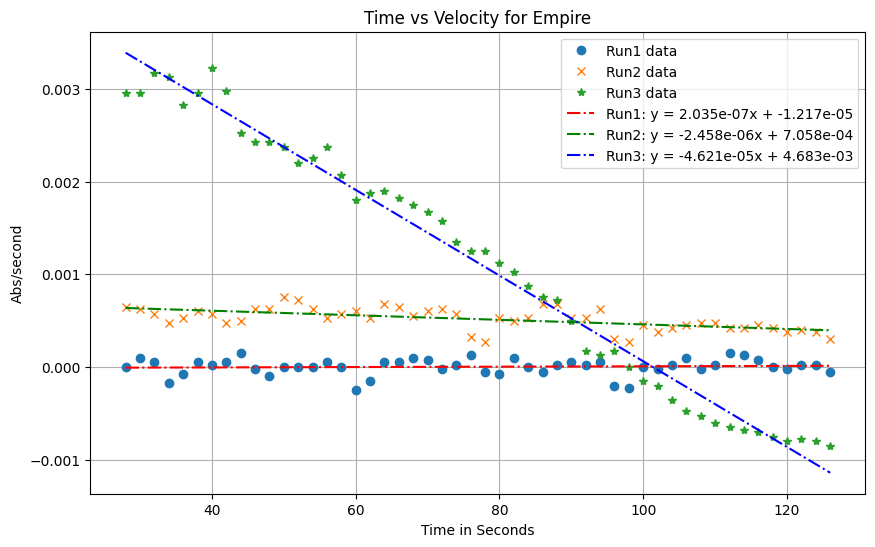

In [ ]:
Run1['yfit'] = Run1_fit.slope * Run1['Time'] + Run1_fit.intercept
Run2['yfit'] = Run2_fit.slope * Run2['Time'] + Run2_fit.intercept
Run3['yfit'] = Run3_fit.slope * Run3['Time'] + Run3_fit.intercept


plt.figure(figsize=(10, 6))
plt.plot(Run1['Time'], Run1['Velocity'], 'o', label='Run1 data')
plt.plot(Run2['Time'], Run2['Velocity'], 'x', label='Run2 data')
plt.plot(Run3['Time'], Run3['Velocity'], '*', label='Run3 data')
plt.plot(Run1['Time'], Run1['yfit'], 'r-.', label=f'Run1: y = {Run1_fit.slope:.3e}x + {Run1_fit.intercept:.3e}')
plt.plot(Run2['Time'], Run2['yfit'], 'g-.', label=f'Run2: y = {Run2_fit.slope:.3e}x + {Run2_fit.intercept:.3e}')
plt.plot(Run3['Time'], Run3['yfit'], 'b-.', label=f'Run3: y = {Run3_fit.slope:.3e}x + {Run3_fit.intercept:.3e}')
plt.title('Velocity vs Time for Empire')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Part IB: What variety of apple would you choose for a fruit salad?

If your goal was to create a fruit salad that had fresh-looking apples, what variety of apples would be best? To answer this question, all the students in this course will divide up into teams. Each team will choose a different variety of apple to study, and the whole class will share data using a shared spreadsheet.

# Set up the Import Options and import the data

You can probably see that entering the filename, number of rows to skip, etc. over and over is tedius.  Here is a better way to do it.  Setup some variables to hold the reused information and let the computer fill it in.

1. **Data directory**: Where your data files are stored
   - If files are in the same folder as this notebook, leave it as `""` (empty string)
   - If files are in a subfolder, set it to the folder name (e.g., `"data"`)

2. **Base filename**: The common part of all your file names (everything before `_Run`)
   - For example, if your files are named like:
     - `20250228_Gala_Run1.txt`
     - `20250228_Gala_Run2.txt`
     - etc.
   - Then your base filename should be `20250228_Gala`

3. **Number of rows to skip**: Specify which row to start reading data from. Usually, a number between 20-25 should work for the first row, but check your plot after import and adjust as necessary.

In [14]:
# Import the data for Part IB
# Here is an easier way to load tons of files:
# Set your data directory (leave empty "" if files are in the same folder as this notebook)
data_directory = "20250227_Part1_EMPIRE"  # For example: "20250227_Part1_Red_Data"

# Set your base filename here (everything before "_Run")
# For example: "20250228_Gala" if your files are "20250228_Gala_Run1.txt"
base_filename = "20250227_Part1_EMPIRE"

# Set the row to start reading data 
skiprows = 21  # This skips the first 21 rows (0-indexed), starts reading at row 22
numrows = 30 # Only read 30 rows of data
separator = "\t"
column_names = ["Time", "Transmittance", "Absorbance"]

# now let the computer fill in all the filenames and settings based on your variables above.

Run4 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run4.txt"), 
                   sep=separator, skiprows=skiprows, nrows=numrows,
                   names=column_names)
Run5 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run5.txt"), 
                   sep=separator, skiprows=skiprows, nrows=numrows,
                   names=column_names)
Run6 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run6.txt"), 
                   sep=separator, skiprows=skiprows, nrows=numrows,
                   names=column_names)
Run7 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run7.txt"), 
                   sep=separator, skiprows=skiprows, nrows=numrows,
                   names=column_names)
Run8 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run8.txt"), 
                   sep=separator, skiprows=skiprows, nrows=numrows,
                   names=column_names)
Run9 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run9.txt"), 
                   sep=separator, skiprows=skiprows, nrows=numrows,
                   names=column_names)
Run10 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run10.txt"), 
                    sep=separator, skiprows=skiprows, nrows=numrows,
                    names=column_names)
Run11 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run11.txt"), 
                    sep=separator, skiprows=skiprows, nrows=numrows,
                    names=column_names)
Run12 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run12.txt"), 
                    sep=separator, skiprows=skiprows, nrows=numrows,
                    names=column_names)
Run13 = pd.read_csv(os.path.join(data_directory, base_filename + "_Run13.txt"), 
                    sep=separator, skiprows=skiprows, nrows=numrows,
                    names=column_names)

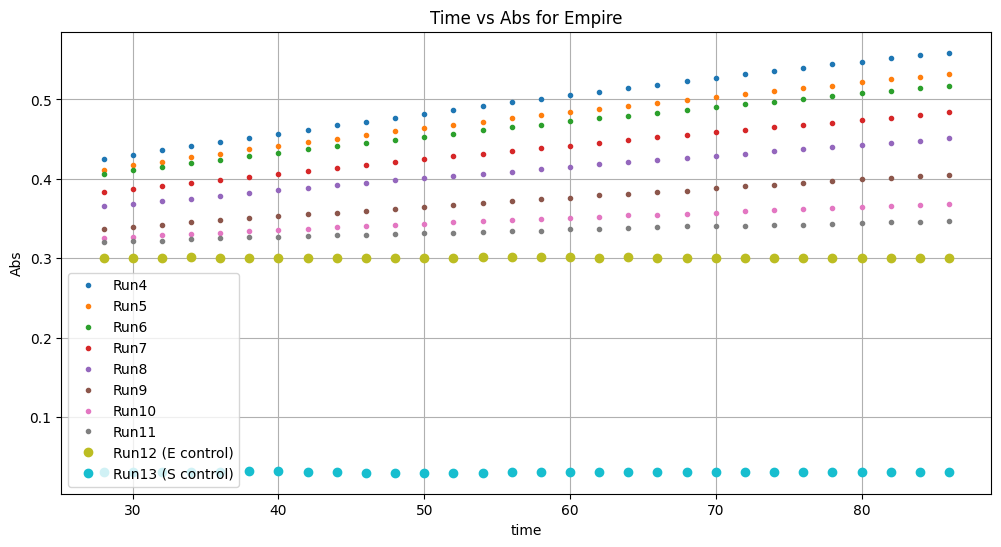

In [15]:
# Extract the data columns from the table and store them as arrays
# time should be the same for all data files, so only import the first
time = Run4['Time'].values
Run4_Abs = Run4['Absorbance'].values
Run5_Abs = Run5['Absorbance'].values
Run6_Abs = Run6['Absorbance'].values
Run7_Abs = Run7['Absorbance'].values
Run8_Abs = Run8['Absorbance'].values
Run9_Abs = Run9['Absorbance'].values
Run10_Abs = Run10['Absorbance'].values
Run11_Abs = Run11['Absorbance'].values
Run12_Abs = Run12['Absorbance'].values
Run13_Abs = Run13['Absorbance'].values

# Plot the data to check correct import
# Remove data points as necessary
plt.figure(figsize=(12, 6))
plt.plot(time, Run4_Abs, '.', label='Run4')
plt.plot(time, Run5_Abs, '.', label='Run5')
plt.plot(time, Run6_Abs, '.', label='Run6')
plt.plot(time, Run7_Abs, '.', label='Run7')
plt.plot(time, Run8_Abs, '.', label='Run8')
plt.plot(time, Run9_Abs, '.', label='Run9')
plt.plot(time, Run10_Abs, '.', label='Run10')
plt.plot(time, Run11_Abs, '.', label='Run11')
plt.plot(time, Run12_Abs, 'o', label='Run12 (E control)')
plt.plot(time, Run13_Abs, 'o', label='Run13 (S control)')
plt.title('Time vs Abs for Empire')
plt.xlabel('time')
plt.ylabel('Abs')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Be sure to change the title and labels appropriately if you use this in your lab notebook

## Velocity (rate)

The velocity at any time is the derivative of the Absorbance with respect to time. We can use the `np.gradient()` function to calculate the derivatives. This function automatically accounts for the time spacing and returns an array of the same size as the input.

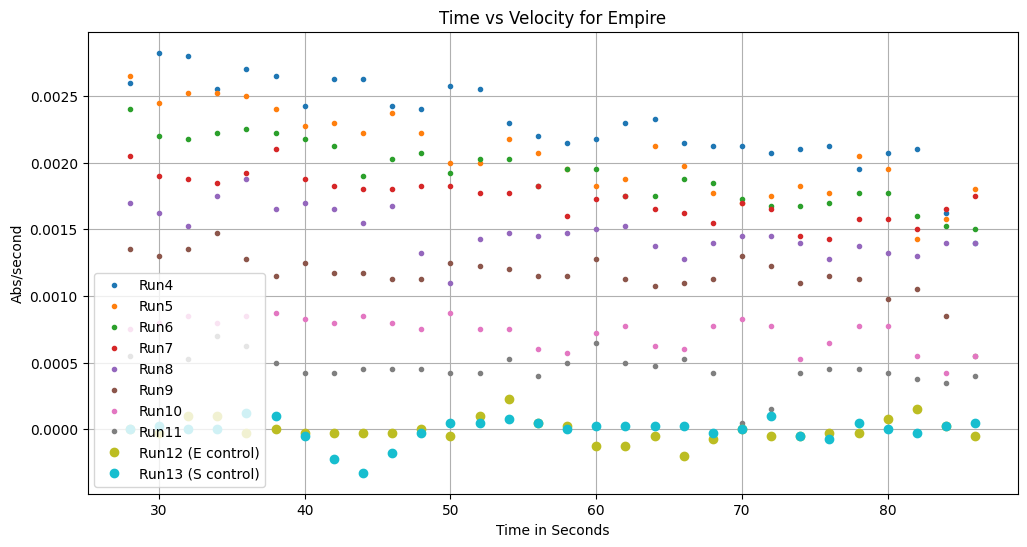

In [16]:
# Calculate velocity using gradient (automatically handles time spacing)
Run4_V = np.gradient(Run4_Abs, time)
Run5_V = np.gradient(Run5_Abs, time)
Run6_V = np.gradient(Run6_Abs, time)
Run7_V = np.gradient(Run7_Abs, time)
Run8_V = np.gradient(Run8_Abs, time)
Run9_V = np.gradient(Run9_Abs, time)
Run10_V = np.gradient(Run10_Abs, time)
Run11_V = np.gradient(Run11_Abs, time)
Run12_V = np.gradient(Run12_Abs, time)
Run13_V = np.gradient(Run13_Abs, time)

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(time, Run4_V, '.', label='Run4')
plt.plot(time, Run5_V, '.', label='Run5')
plt.plot(time, Run6_V, '.', label='Run6')
plt.plot(time, Run7_V, '.', label='Run7')
plt.plot(time, Run8_V, '.', label='Run8')
plt.plot(time, Run9_V, '.', label='Run9')
plt.plot(time, Run10_V, '.', label='Run10')
plt.plot(time, Run11_V, '.', label='Run11')
plt.plot(time, Run12_V, 'o', label='Run12 (E control)')
plt.plot(time, Run13_V, 'o', label='Run13 (S control)')
plt.title('Time vs Velocity for Empire')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Linear fitting of Velocity vs Time for each run

Use linear regression to fit a straight line to the data

In [17]:
# Fit Time vs Velocity data using linear regression
Run4_fit = stats.linregress(time, Run4_V)
Run4_yfit = Run4_fit.slope * time + Run4_fit.intercept

Run5_fit = stats.linregress(time, Run5_V)
Run5_yfit = Run5_fit.slope * time + Run5_fit.intercept

Run6_fit = stats.linregress(time, Run6_V)
Run6_yfit = Run6_fit.slope * time + Run6_fit.intercept

Run7_fit = stats.linregress(time, Run7_V)
Run7_yfit = Run7_fit.slope * time + Run7_fit.intercept

Run8_fit = stats.linregress(time, Run8_V)
Run8_yfit = Run8_fit.slope * time + Run8_fit.intercept

Run9_fit = stats.linregress(time, Run9_V)
Run9_yfit = Run9_fit.slope * time + Run9_fit.intercept

Run10_fit = stats.linregress(time, Run10_V)
Run10_yfit = Run10_fit.slope * time + Run10_fit.intercept

Run11_fit = stats.linregress(time, Run11_V)
Run11_yfit = Run11_fit.slope * time + Run11_fit.intercept

Run12_fit = stats.linregress(time, Run12_V)
Run12_yfit = Run12_fit.slope * time + Run12_fit.intercept

Run13_fit = stats.linregress(time, Run13_V)
Run13_yfit = Run13_fit.slope * time + Run13_fit.intercept

# Display fit statistics for all runs
for i, fit in enumerate([Run4_fit, Run5_fit, Run6_fit, Run7_fit, Run8_fit, 
                         Run9_fit, Run10_fit, Run11_fit, Run12_fit, Run13_fit], start=4):
    print(f"\nRun{i} fit statistics:")
    print(f"  Slope: {fit.slope:.6e} ± {fit.stderr:.6e}")
    print(f"  Intercept: {fit.intercept:.6e} ± {fit.intercept_stderr:.6e}")
    print(f"  R-squared: {fit.rvalue**2:.6f}")


Run4 fit statistics:
  Slope: -1.675193e-05 ± 1.492636e-06
  Intercept: 3.256526e-03 ± 8.891735e-05
  R-squared: 0.818131

Run5 fit statistics:
  Slope: -1.588711e-05 ± 1.441438e-06
  Intercept: 2.974733e-03 ± 8.586744e-05
  R-squared: 0.812682

Run6 fit statistics:
  Slope: -1.256393e-05 ± 8.291413e-07
  Intercept: 2.637811e-03 ± 4.939251e-05
  R-squared: 0.891309

Run7 fit statistics:
  Slope: -7.647261e-06 ± 9.713650e-07
  Intercept: 2.175895e-03 ± 5.786488e-05
  R-squared: 0.688817

Run8 fit statistics:
  Slope: -6.468257e-06 ± 1.319260e-06
  Intercept: 1.848691e-03 ± 7.858924e-05
  R-squared: 0.461940

Run9 fit statistics:
  Slope: -6.607312e-06 ± 1.271062e-06
  Intercept: 1.534951e-03 ± 7.571805e-05
  R-squared: 0.491112

Run10 fit statistics:
  Slope: -4.338152e-06 ± 9.774386e-07
  Intercept: 9.756072e-04 ± 5.822669e-05
  R-squared: 0.412978

Run11 fit statistics:
  Slope: -3.278640e-06 ± 1.173163e-06
  Intercept: 6.360497e-04 ± 6.988614e-05
  R-squared: 0.218103

Run12 fit sta

## Extract initial velocities and standard errors

In [18]:
# This extracts the initial velocity and standard error
V0_Run4 = Run4_fit.intercept  # initial velocity
V0_Run4_err = Run4_fit.intercept_stderr  # standard error
V0_Run5 = Run5_fit.intercept
V0_Run5_err = Run5_fit.intercept_stderr
V0_Run6 = Run6_fit.intercept
V0_Run6_err = Run6_fit.intercept_stderr
V0_Run7 = Run7_fit.intercept
V0_Run7_err = Run7_fit.intercept_stderr
V0_Run8 = Run8_fit.intercept
V0_Run8_err = Run8_fit.intercept_stderr
V0_Run9 = Run9_fit.intercept
V0_Run9_err = Run9_fit.intercept_stderr
V0_Run10 = Run10_fit.intercept
V0_Run10_err = Run10_fit.intercept_stderr
V0_Run11 = Run11_fit.intercept
V0_Run11_err = Run11_fit.intercept_stderr
V0_Run12 = Run12_fit.intercept
V0_Run12_err = Run12_fit.intercept_stderr
V0_Run13 = Run13_fit.intercept
V0_Run13_err = Run13_fit.intercept_stderr

# Extract the initial velocity from each linear fit and set as a new variable
V0_Run4_raw = Run4_fit.intercept
V0_Run5_raw = Run5_fit.intercept
V0_Run6_raw = Run6_fit.intercept
V0_Run7_raw = Run7_fit.intercept
V0_Run8_raw = Run8_fit.intercept
V0_Run9_raw = Run9_fit.intercept
V0_Run10_raw = Run10_fit.intercept
V0_Run11_raw = Run11_fit.intercept
V0_Run12_raw = Run12_fit.intercept
V0_Run13_raw = Run13_fit.intercept

## Optional baseline correction

Only correct if you decide it is necessary. Uncomment the lines below to apply correction.

In [19]:
# Optional correction: only correct if you decide it is necessary
# To correct, uncomment the lines below
# controls = [V0_Run12, V0_Run13]
# baseline = np.mean(controls)
# V0_Run4 = V0_Run4_raw - baseline
# V0_Run5 = V0_Run5_raw - baseline
# V0_Run6 = V0_Run6_raw - baseline
# V0_Run7 = V0_Run7_raw - baseline
# V0_Run8 = V0_Run8_raw - baseline
# V0_Run9 = V0_Run9_raw - baseline
# V0_Run10 = V0_Run10_raw - baseline
# V0_Run11 = V0_Run11_raw - baseline
# V0_Run12 = V0_Run12_raw - baseline
# V0_Run13 = V0_Run13_raw - baseline

V0_Run4 = V0_Run4_raw
V0_Run5 = V0_Run5_raw
V0_Run6 = V0_Run6_raw
V0_Run7 = V0_Run7_raw
V0_Run8 = V0_Run8_raw
V0_Run9 = V0_Run9_raw
V0_Run10 = V0_Run10_raw
V0_Run11 = V0_Run11_raw
V0_Run12 = V0_Run12_raw
V0_Run13 = V0_Run13_raw

# Display results
print(f'V0 Run4: {V0_Run4:.2e} ± {V0_Run4_err:.2e}')
print(f'V0 Run5: {V0_Run5:.2e} ± {V0_Run5_err:.2e}')
print(f'V0 Run6: {V0_Run6:.2e} ± {V0_Run6_err:.2e}')
print(f'V0 Run7: {V0_Run7:.2e} ± {V0_Run7_err:.2e}')
print(f'V0 Run8: {V0_Run8:.2e} ± {V0_Run8_err:.2e}')
print(f'V0 Run9: {V0_Run9:.2e} ± {V0_Run9_err:.2e}')
print(f'V0 Run10: {V0_Run10:.2e} ± {V0_Run10_err:.2e}')
print(f'V0 Run11: {V0_Run11:.2e} ± {V0_Run11_err:.2e}')
print(f'V0 Run12: {V0_Run12:.2e} ± {V0_Run12_err:.2e}')
print(f'V0 Run13: {V0_Run13:.2e} ± {V0_Run13_err:.2e}')

V0 Run4: 3.26e-03 ± 8.89e-05
V0 Run5: 2.97e-03 ± 8.59e-05
V0 Run6: 2.64e-03 ± 4.94e-05
V0 Run7: 2.18e-03 ± 5.79e-05
V0 Run8: 1.85e-03 ± 7.86e-05
V0 Run9: 1.53e-03 ± 7.57e-05
V0 Run10: 9.76e-04 ± 5.82e-05
V0 Run11: 6.36e-04 ± 6.99e-05
V0 Run12: 2.71e-05 ± 5.36e-05
V0 Run13: -4.78e-05 ± 5.95e-05


## Plot Velocity vs Time for experiments with different [S₀]

Check the data and the plot features. Adjust as necessary.

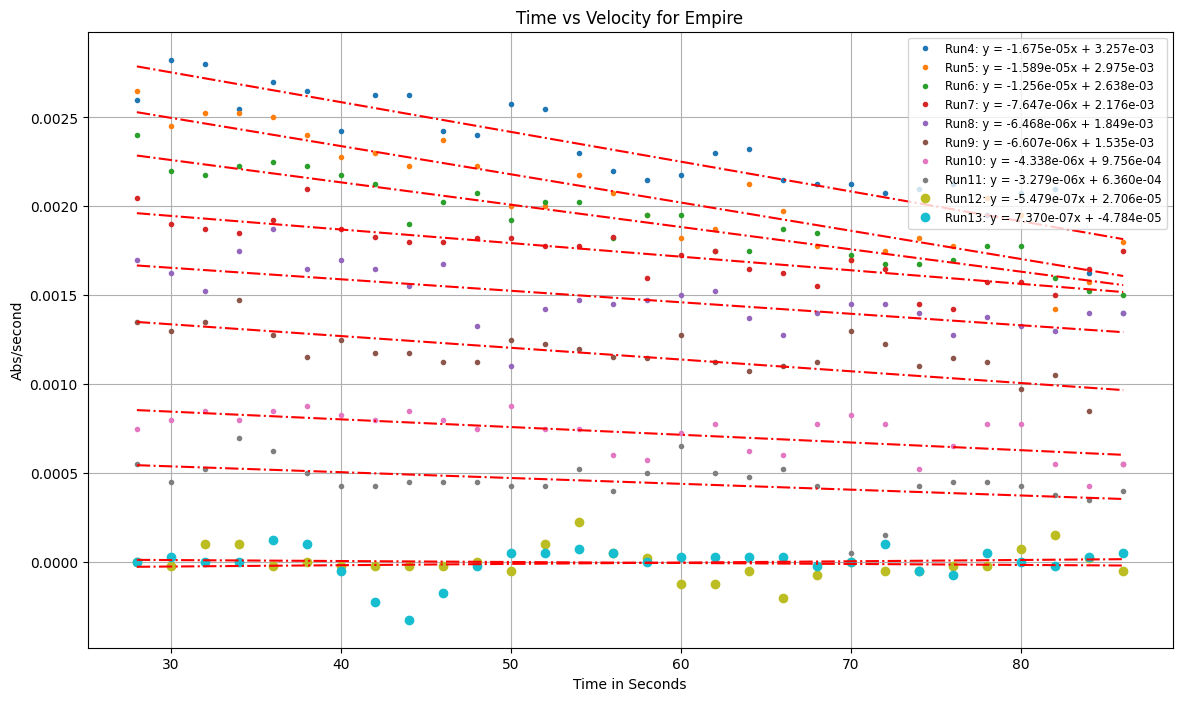

In [20]:
plt.figure(figsize=(14, 8))
plt.plot(time, Run4_V, '.', label=f'Run4: y = {Run4_fit.slope:.3e}x + {Run4_fit.intercept:.3e}')
plt.plot(time, Run5_V, '.', label=f'Run5: y = {Run5_fit.slope:.3e}x + {Run5_fit.intercept:.3e}')
plt.plot(time, Run6_V, '.', label=f'Run6: y = {Run6_fit.slope:.3e}x + {Run6_fit.intercept:.3e}')
plt.plot(time, Run7_V, '.', label=f'Run7: y = {Run7_fit.slope:.3e}x + {Run7_fit.intercept:.3e}')
plt.plot(time, Run8_V, '.', label=f'Run8: y = {Run8_fit.slope:.3e}x + {Run8_fit.intercept:.3e}')
plt.plot(time, Run9_V, '.', label=f'Run9: y = {Run9_fit.slope:.3e}x + {Run9_fit.intercept:.3e}')
plt.plot(time, Run10_V, '.', label=f'Run10: y = {Run10_fit.slope:.3e}x + {Run10_fit.intercept:.3e}')
plt.plot(time, Run11_V, '.', label=f'Run11: y = {Run11_fit.slope:.3e}x + {Run11_fit.intercept:.3e}')
plt.plot(time, Run12_V, 'o', label=f'Run12: y = {Run12_fit.slope:.3e}x + {Run12_fit.intercept:.3e}')
plt.plot(time, Run13_V, 'o', label=f'Run13: y = {Run13_fit.slope:.3e}x + {Run13_fit.intercept:.3e}')
plt.plot(time, Run4_yfit, 'r-.')
plt.plot(time, Run5_yfit, 'r-.')
plt.plot(time, Run6_yfit, 'r-.')
plt.plot(time, Run7_yfit, 'r-.')
plt.plot(time, Run8_yfit, 'r-.')
plt.plot(time, Run9_yfit, 'r-.')
plt.plot(time, Run10_yfit, 'r-.')
plt.plot(time, Run11_yfit, 'r-.')
plt.plot(time, Run12_yfit, 'r-.')
plt.plot(time, Run13_yfit, 'r-.')
plt.title('Time vs Velocity for Empire')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.show()

# Michaelis-Menten

The Michaelis-Menten equation is typically represented as:

$$v = \frac{V_{\max} \cdot [S]}{K_m + [S]}$$

where $v$ is the reaction rate, $V_{\max}$ is the maximum reaction rate, $[S]$ is the substrate concentration, and $K_m$ is the Michaelis constant.

First, we need to calculate the initial substrate concentrations in each of the runs. The code below does this with the proper user inputs. And, it generates a vector of the initial concentrations ($[S_0]$) and corresponding vector of initial rates ($V_0$).

In [21]:
# Enter concentrations and volumes
MW = 110.1  # molecular weight of substrate
stock_S_mgL = 509.2  # concentration (mg/L) of substrate stock solution
stock_S = stock_S_mgL / MW / 1000  # in M

# Enter volumes (V) of substrate in mL
TotV = 2.50  # total volume in cuvette (mL)
Vol4 = 1.75   # volume of substrate added in run 4
Vol5 = 1.50   # volume of substrate added in run 5
Vol6 = 1.25
Vol7 = 1.00
Vol8 = 0.75
Vol9 = 0.50
Vol10 = 0.25
Vol11 = 0.125
Vol12 = 0.0
Vol13 = 0.0

# Calculate concentration of Substrate in M
S4 = Vol4 * stock_S / TotV
S5 = Vol5 * stock_S / TotV
S6 = Vol6 * stock_S / TotV
S7 = Vol7 * stock_S / TotV
S8 = Vol8 * stock_S / TotV
S9 = Vol9 * stock_S / TotV
S10 = Vol10 * stock_S / TotV
S11 = Vol11 * stock_S / TotV
S12 = Vol12 * stock_S / TotV
S13 = Vol13 * stock_S / TotV

# Define as arrays
S0 = np.array([S4, S5, S6, S7, S8, S9, S10, S11, S12])  # initial substrate conc in M
V0 = np.array([V0_Run4, V0_Run5, V0_Run6, V0_Run7, V0_Run8, V0_Run9, V0_Run10, V0_Run11, V0_Run12])

# Uncomment to display arrays
# print("S0:", S0)
# print("V0:", V0)

## Visualize the data in a plot

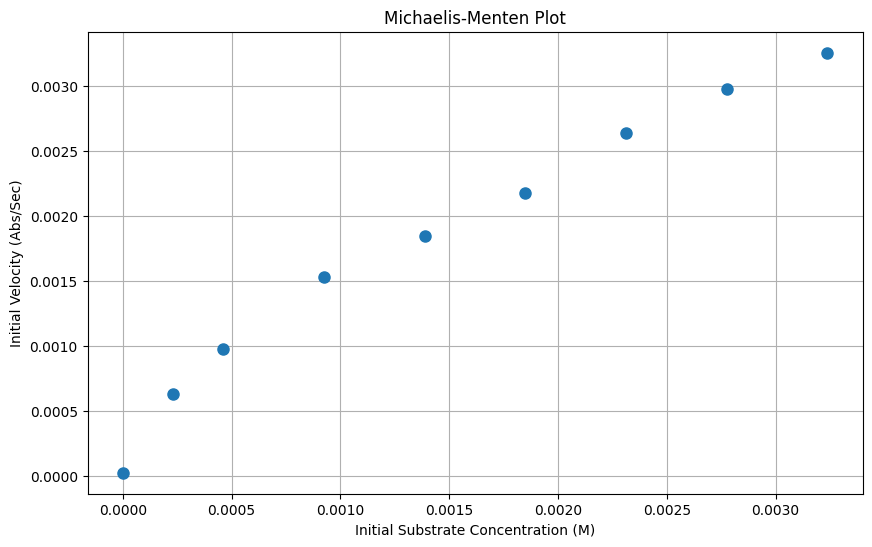

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(S0, V0, 'o', markersize=8)
plt.title('Michaelis-Menten Plot')
plt.xlabel('Initial Substrate Concentration (M)')
plt.ylabel('Initial Velocity (Abs/Sec)')
plt.grid(True)
plt.show()

# We can use the max value of the V0 array as an approximation of the Vmax
# This can help with fitting below
Vmax_guess = np.max(V0)
# print(f"Vmax guess: {Vmax_guess}")

# get a feeling for fitting.  Use the sliders to adjust the Vmax and Km

## Michaelis-Menten Least Squares Fitting

Fit the data using non-linear least squares

In [23]:
# Define the Michaelis-Menten function
def michaelis_menten(S, Vmax, Km):
    """Michaelis-Menten equation: v = Vmax*S/(Km+S)"""
    return Vmax * S / (Km + S)

# Initial guess for parameters [Vmax, Km]
p0 = [0.005, 0.006]

# Fit the data
popt_MM, pcov_MM = curve_fit(michaelis_menten, S0, V0, p0=p0, maxfev=10000)
Vmax_fit, Km_fit = popt_MM

# Calculate confidence intervals (standard errors)
perr_MM = np.sqrt(np.diag(pcov_MM))
Vmax_err, Km_err = perr_MM

# Calculate 95% confidence intervals (approximately 2 * standard error)
Vmax_conf = 1.96 * Vmax_err
Km_conf = 1.96 * Km_err

# Display results
print(f'\nMichaelis-Menten Fit Results:')
print(f'Fitted Vmax: {Vmax_fit:.2e} ± {Vmax_conf:.2e}')
print(f'Fitted Km: {Km_fit:.2e} ± {Km_conf:.2e}')

# Create DataFrame with coefficients
coefficients_table = pd.DataFrame({
    'Vmax': [Vmax_fit, Vmax_fit - Vmax_conf, Vmax_fit + Vmax_conf],
    'Km': [Km_fit, Km_fit - Km_conf, Km_fit + Km_conf]
}, index=['Coefficient', 'Lower Bound', 'Upper Bound'])
print('\n', coefficients_table)


Michaelis-Menten Fit Results:
Fitted Vmax: 5.78e-03 ± 1.33e-03
Fitted Km: 2.69e-03 ± 1.12e-03

                  Vmax        Km
Coefficient  0.005777  0.002693
Lower Bound  0.004450  0.001577
Upper Bound  0.007104  0.003808


## Plot fit with data

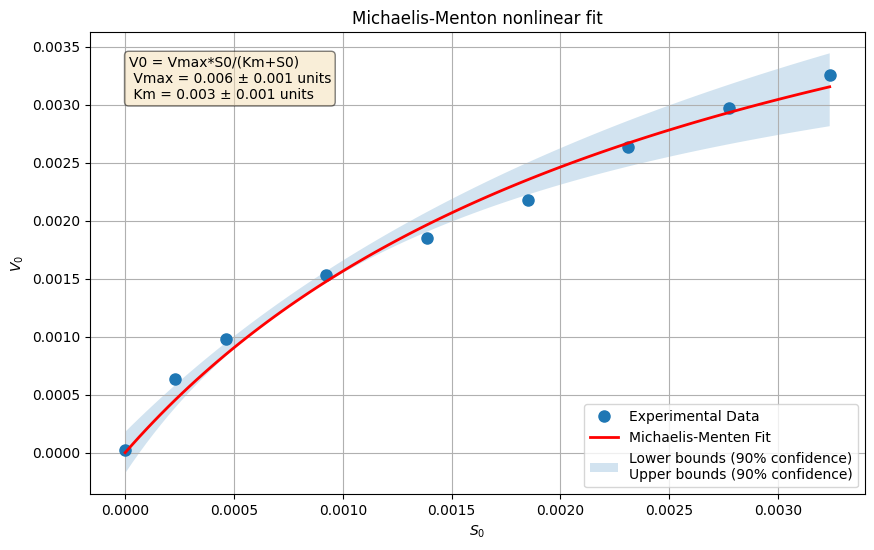

In [24]:
# Generate points for the fitted curve
S_fit = np.linspace(S0.min(), S0.max(), 100)
V_fit = michaelis_menten(S_fit, Vmax_fit, Km_fit)

# Calculate prediction bounds (approximate 90% confidence)
# For simplicity, we'll calculate upper and lower bounds
residuals = V0 - michaelis_menten(S0, Vmax_fit, Km_fit)
residual_std = np.std(residuals)
V_fit_upper = michaelis_menten(S_fit, Vmax_fit + Vmax_conf, Km_fit + Km_conf) + 1.645 * residual_std
V_fit_lower = michaelis_menten(S_fit, Vmax_fit - Vmax_conf, Km_fit - Km_conf) - 1.645 * residual_std

plt.figure(figsize=(10, 6))
plt.plot(S0, V0, 'o', label='Experimental Data', markersize=8)
plt.plot(S_fit, V_fit, 'r-', label='Michaelis-Menten Fit', linewidth=2)
plt.fill_between(S_fit, V_fit_lower, V_fit_upper, alpha=0.2, 
                 label='Lower bounds (90% confidence)\nUpper bounds (90% confidence)')
plt.xlabel('$S_0$')
plt.ylabel('$V_0$')
plt.title('Michaelis-Menton nonlinear fit')
plt.legend(loc='best')
plt.grid(True)

# Add text box with equations
textstr = f'V0 = Vmax*S0/(Km+S0)\n Vmax = {Vmax_fit:.3f} ± {Vmax_conf:.3f} units\n Km = {Km_fit:.3f} ± {Km_conf:.3f} units'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)
plt.show()

## Plot residuals

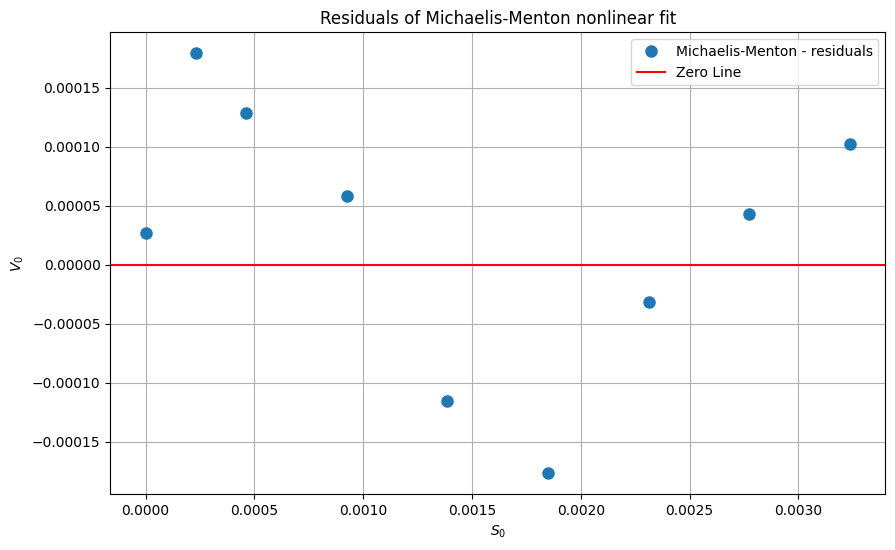

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(S0, residuals, 'o', markersize=8, label='Michaelis-Menton - residuals')
plt.axhline(y=0, color='r', linestyle='-', label='Zero Line')
plt.xlabel('$S_0$')
plt.ylabel('$V_0$')
plt.title('Residuals of Michaelis-Menton nonlinear fit')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Lineweaver-Burke

The Lineweaver-Burke plot is a linearization of the Michaelis-Menten equation. In an era before computers could do non-linear fitting, most scientists used this method to determine Km and Vmax. However, it is highly criticized because its use applies the wrong statistical model to interpret the data. Though its use to derive constants is not advised, it is useful for visualizing the effect of substrate or inhibitor concentration on kinetic rate data (especially for part II).

## Prepare the data:

In the arrays below, you may need to delete data from the highest concentrations of substrate because they may lie outside of the linear portion of the L-B plot. The code to do this is below, and you may need to uncomment some lines to remove more data points.

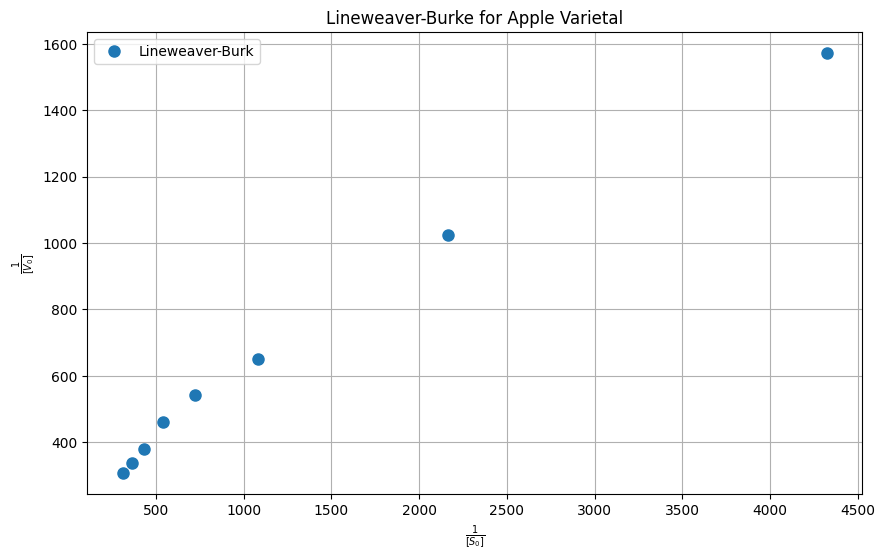

In [26]:
inverse_S0 = 1.0 / S0
inverse_V0 = 1.0 / V0

# Delete 1/0 = infinity and adjust arrays
# Remove the last element (index 8, which is S12)
inverse_S0 = np.delete(inverse_S0, 8)  # adjust index as needed
inverse_V0 = np.delete(inverse_V0, 8)  # adjust index as needed

# Uncomment the lines below to remove more data points if necessary
# inverse_S0 = np.delete(inverse_S0, 7)
# inverse_V0 = np.delete(inverse_V0, 7)
# inverse_S0 = np.delete(inverse_S0, 6)
# inverse_V0 = np.delete(inverse_V0, 6)

# Plot the result and visually check for approximate linearity
plt.figure(figsize=(10, 6))
plt.plot(inverse_S0, inverse_V0, 'o', markersize=8, label='Lineweaver-Burk')
plt.title('Lineweaver-Burke for Apple Varietal')
plt.xlabel('$\\frac{1}{[S_0]}$')
plt.ylabel('$\\frac{1}{[V_0]}$')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Fit the linearized data

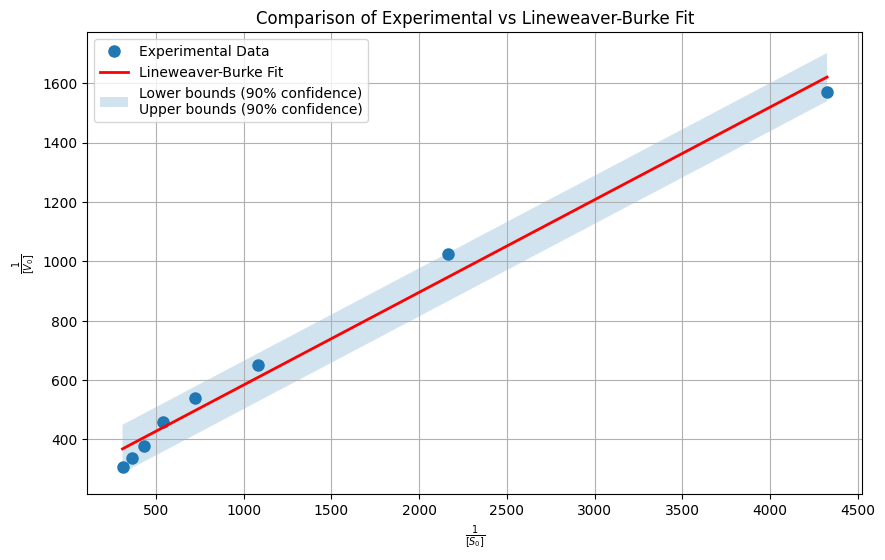

In [27]:
# Perform linear regression
LB_fit = stats.linregress(inverse_S0, inverse_V0)

# Generate fitted line
inverse_S0_plot = inverse_S0
inverse_V0_fit = LB_fit.slope * inverse_S0_plot + LB_fit.intercept

# Calculate prediction intervals (approximate 90% confidence)
LB_residuals = inverse_V0 - inverse_V0_fit
LB_residual_std = np.std(LB_residuals)
t_val = 1.645  # approximate 90% confidence for large samples
inverse_V0_upper = inverse_V0_fit + t_val * LB_residual_std
inverse_V0_lower = inverse_V0_fit - t_val * LB_residual_std

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(inverse_S0, inverse_V0, 'o', markersize=8, label='Experimental Data')
plt.plot(inverse_S0_plot, inverse_V0_fit, 'r-', linewidth=2, label='Lineweaver-Burke Fit')
plt.fill_between(inverse_S0_plot, inverse_V0_lower, inverse_V0_upper, alpha=0.2,
                 label='Lower bounds (90% confidence)\nUpper bounds (90% confidence)')
plt.xlabel('$\\frac{1}{[S_0]}$')
plt.ylabel('$\\frac{1}{[V_0]}$')
plt.title('Comparison of Experimental vs Lineweaver-Burke Fit')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Use the code blocks above as examples of how you can add an annotation or text to the plot.

## Plot residuals

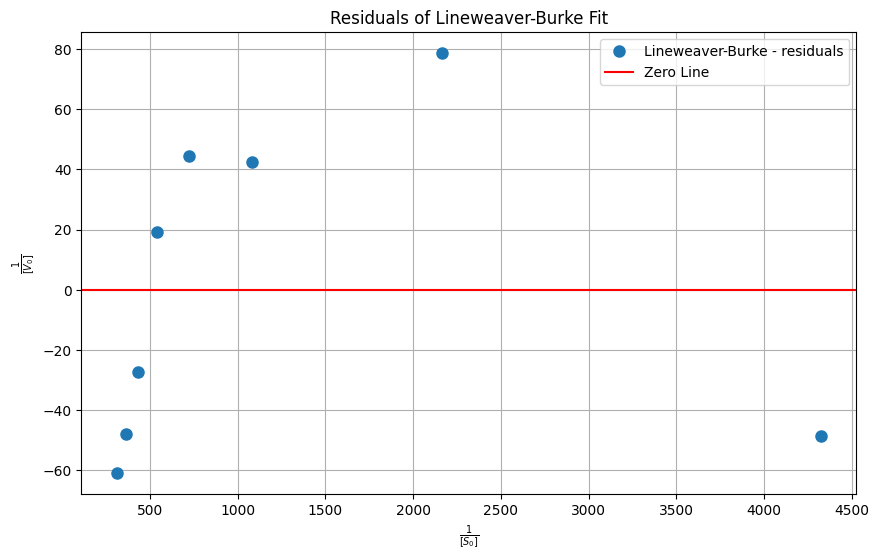

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(inverse_S0, LB_residuals, 'o', markersize=8, label='Lineweaver-Burke - residuals')
plt.axhline(y=0, color='r', linestyle='-', label='Zero Line')
plt.xlabel('$\\frac{1}{[S_0]}$')
plt.ylabel('$\\frac{1}{[V_0]}$')
plt.title('Residuals of Lineweaver-Burke Fit')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Summary

Create a summary figure with all plots

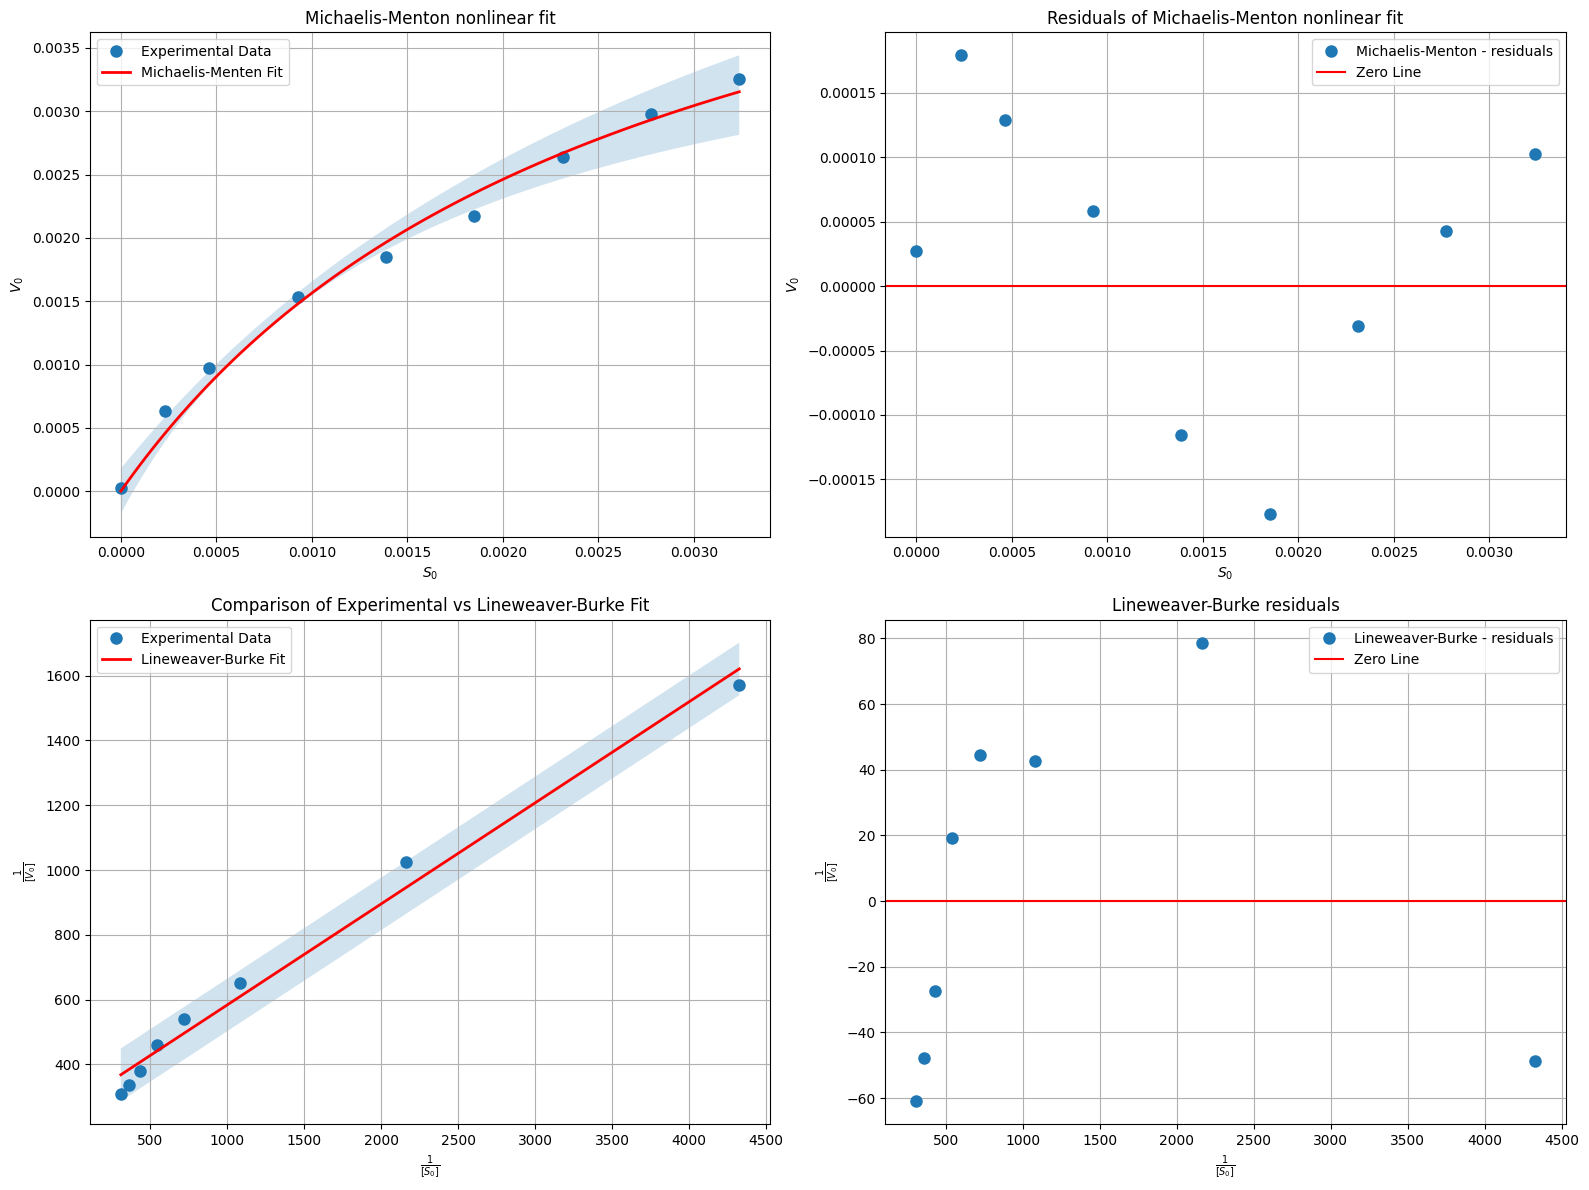

In [29]:
fig = plt.figure(figsize=(16, 12))

# Plot MM
ax1 = plt.subplot(2, 2, 1)
ax1.plot(S0, V0, 'o', label='Experimental Data', markersize=8)
ax1.plot(S_fit, V_fit, 'r-', label='Michaelis-Menten Fit', linewidth=2)
ax1.fill_between(S_fit, V_fit_lower, V_fit_upper, alpha=0.2)
ax1.set_xlabel('$S_0$')
ax1.set_ylabel('$V_0$')
ax1.set_title('Michaelis-Menton nonlinear fit')
ax1.legend(loc='best')
ax1.grid(True)

# Plot MM residuals
ax2 = plt.subplot(2, 2, 2)
ax2.plot(S0, residuals, 'o', markersize=8)
ax2.axhline(y=0, color='r', linestyle='-')
ax2.set_xlabel('$S_0$')
ax2.set_ylabel('$V_0$')
ax2.set_title('Residuals of Michaelis-Menton nonlinear fit')
ax2.legend(['Michaelis-Menton - residuals', 'Zero Line'], loc='best')
ax2.grid(True)

# Plot LB
ax3 = plt.subplot(2, 2, 3)
ax3.plot(inverse_S0, inverse_V0, 'o', markersize=8, label='Experimental Data')
ax3.plot(inverse_S0_plot, inverse_V0_fit, 'r-', linewidth=2, label='Lineweaver-Burke Fit')
ax3.fill_between(inverse_S0_plot, inverse_V0_lower, inverse_V0_upper, alpha=0.2)
ax3.set_xlabel('$\\frac{1}{[S_0]}$')
ax3.set_ylabel('$\\frac{1}{[V_0]}$')
ax3.set_title('Comparison of Experimental vs Lineweaver-Burke Fit')
ax3.legend(loc='best')
ax3.grid(True)

# Plot LB residuals
ax4 = plt.subplot(2, 2, 4)
ax4.plot(inverse_S0, LB_residuals, 'o', markersize=8)
ax4.axhline(y=0, color='r', linestyle='-')
ax4.set_xlabel('$\\frac{1}{[S_0]}$')
ax4.set_ylabel('$\\frac{1}{[V_0]}$')
ax4.set_title('Lineweaver-Burke residuals')
ax4.legend(['Lineweaver-Burke - residuals', 'Zero Line'], loc='best')
ax4.grid(True)

plt.tight_layout()
plt.show()

# Convert Lineweaver-Burke result to Michaelis-Menten Plot

In [30]:
# Generate data points for linear LB fit
inverseS0all = 1.0 / S0

# Create a linear model for LB fit
LB_fit_full = stats.linregress(inverse_S0, inverse_V0)
print(f"\nLineweaver-Burke fit statistics:")
print(f"  Slope: {LB_fit_full.slope:.6e} ± {LB_fit_full.stderr:.6e}")
print(f"  Intercept: {LB_fit_full.intercept:.6e} ± {LB_fit_full.intercept_stderr:.6e}")
print(f"  R-squared: {LB_fit_full.rvalue**2:.6f}")

LB_yfit = LB_fit_full.slope * inverseS0all + LB_fit_full.intercept

# Take inverse of LB fitted points
LB_V0 = 1.0 / LB_yfit


Lineweaver-Burke fit statistics:
  Slope: 3.120215e-01 ± 1.554438e-02
  Intercept: 2.716168e+02 ± 2.789806e+01
  R-squared: 0.985327


## Plot MM vs LB fits with S0 vs V0 data

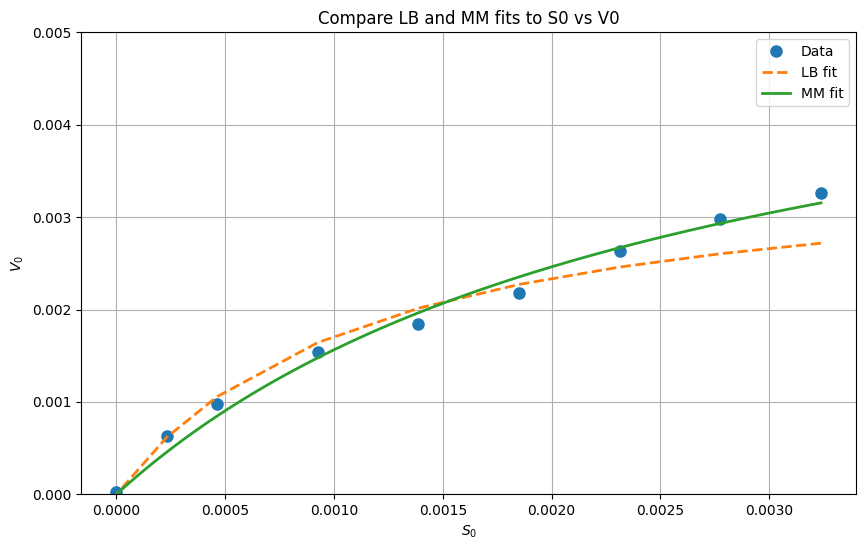

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(S0, V0, 'o', markersize=8, label='Data')
plt.plot(S0, LB_V0, '--', linewidth=2, label='LB fit')
plt.plot(S_fit, V_fit, '-', linewidth=2, label='MM fit')
plt.xlabel('$S_0$')
plt.ylabel('$V_0$')
plt.title('Compare LB and MM fits to S0 vs V0')
plt.legend(loc='best')
plt.grid(True)
plt.ylim([0, 0.005])
plt.show()